#### Step 1: Set up hylite and download data to GoogleColab

Install *hylite* in this GoogleColab environment and download the demonstration data.

In [ ]:
# if running via Google Colab then we need to set up the machine as follows
!pip install git+https://github.com/samthiele/hylite.git
!pip install h5py # used for loading hdf5 files

# clear output (it isn't easy being clean!)
from IPython.display import clear_output
clear_output()

In [ ]:
# download example Prisma scene
# https://drive.google.com/file/d/1G9q-yoPl04JelKMVh53KW35paiqo3Kp2/view?usp=drive_link
!pip install --upgrade gdown
!gdown 1G9q-yoPl04JelKMVh53KW35paiqo3Kp2
clear_output()

In [ ]:
# check hylite import
import hylite
import h5py

### LOAD HSI DATA FROM PRISMA HDF5 FILE

Now lets load a PRISMA file!

In [ ]:
import h5py
import numpy as np
import hylite
import hylite.io as io
import matplotlib.pyplot as plt

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
MAIN = '/content/' # root directory
hdf= MAIN + 'PRS_L2D_STD_20201021090538_20201021090542_0001.he5' # file

In [ ]:
# open the container
f=h5py.File(hdf, "r")

In [ ]:
# retrieve geolocation information
easting = f.attrs['Product_ULcorner_easting']
northing = f.attrs['Product_ULcorner_northing']
UTM_zone = int(f.attrs['Projection_Id'])
epsg = 'EPSG:'+ str(f.attrs['Epsg_Code'])

# retrieve data and important metadata
wl_VNIR = np.flipud(f.attrs['List_Cw_Vnir'])
wl_SWIR = np.flipud(f.attrs['List_Cw_Swir'])
VNIR_valid = np.argwhere(wl_VNIR>0.)[:,0]
SWIR_valid = np.argwhere((wl_SWIR>0.) *(wl_SWIR>np.amax(wl_VNIR)))[:,0]
wl = np.hstack((wl_VNIR[VNIR_valid],wl_SWIR[SWIR_valid]))

VNIRdata = f['/HDFEOS/SWATHS/PRS_L2D_HCO/Data Fields/VNIR_Cube'][:,:,:]
SWIRdata = f['/HDFEOS/SWATHS/PRS_L2D_HCO/Data Fields/SWIR_Cube'][:,:,:]
VNIRdata = np.transpose(VNIRdata, (2,0,1))[...,::-1][...,VNIR_valid]
SWIRdata = np.transpose(SWIRdata, (2,0,1))[...,::-1][...,SWIR_valid]
VNIRdata.shape, SWIRdata.shape
HSI = np.dstack((VNIRdata, SWIRdata))

In [ ]:
# there are a lot more if needed ;)
for i in f.attrs:
    print(i)

Acquisition_Purpose
Acquisition_Size
Acquisition_Station
Acquisition_Type
Atm_LutGeomInfo_RelativeAzimuth
Atm_LutGeomInfo_SunZenith
Atm_LutGeomInfo_ViewZenith
Atm_Lut_version
Atmo_RTM_info
Atmo_profile_info
Aux_SunEarthDistance
Aux_SunIrradiance
CNM_L2_BINNING
CNM_L2_BIN_ON
CNM_L2_BSEL_ON
CNM_L2_HGRP
CNM_PAN_ACQ
CNM_SWIR_ACQ
CNM_SWIR_SELECT
CNM_VNIR_ACQ
CNM_VNIR_SELECT
Cloudy_pixels_percentage
DEM_info
Epsg_Code
Exit_Code
Frame_Type
GCP_info
ISF_ID_Start
Image_ID
Integration_Time
L1_Processor_Version
L1_Quality_CCPerc
L2ScalePanMax
L2ScalePanMin
L2ScaleSwirMax
L2ScaleSwirMin
L2ScaleVnirMax
L2ScaleVnirMin
L2d_Quality_flags
List_Cw_Swir
List_Cw_Swir_Flags
List_Cw_Vnir
List_Cw_Vnir_Flags
List_Fwhm_Swir
List_Fwhm_Vnir
Main_Electornic_Unit
Map_AOT_accuracy
Map_WV_accuracy
Num_Frames
Number_of_ISF
PANCorruptedFrameList
PAN_ACQ
PAN_Corrupted_Frame_Percentage
PAN_HGRP
PAN_HYP_ACT_RESIDUAL_m
PAN_HYP_ALT_RESIDUAL_m
PAN_HYP_START_SYNC_FRAME
PAN_HYP_START_SYNC_SUBFRAME
PAN_HYP_STOP_SYNC_FRAME
PAN_

### TRANSFER TO HYIMAGE

In [ ]:
HSI_im = io.HyImage(HSI)
#HSI_im.data=HSI_im.data.astype(np.float)
HSI_im.set_wavelengths(wl)
HSI_im.set_projection_EPSG(epsg) # adjust the projection if needed
HSI_im.affine = [easting, 30., 0, northing, 0.,-30.]

(<Figure size 1800x600 with 1 Axes>, <Axes: xlabel='Wavelength (nm)'>)

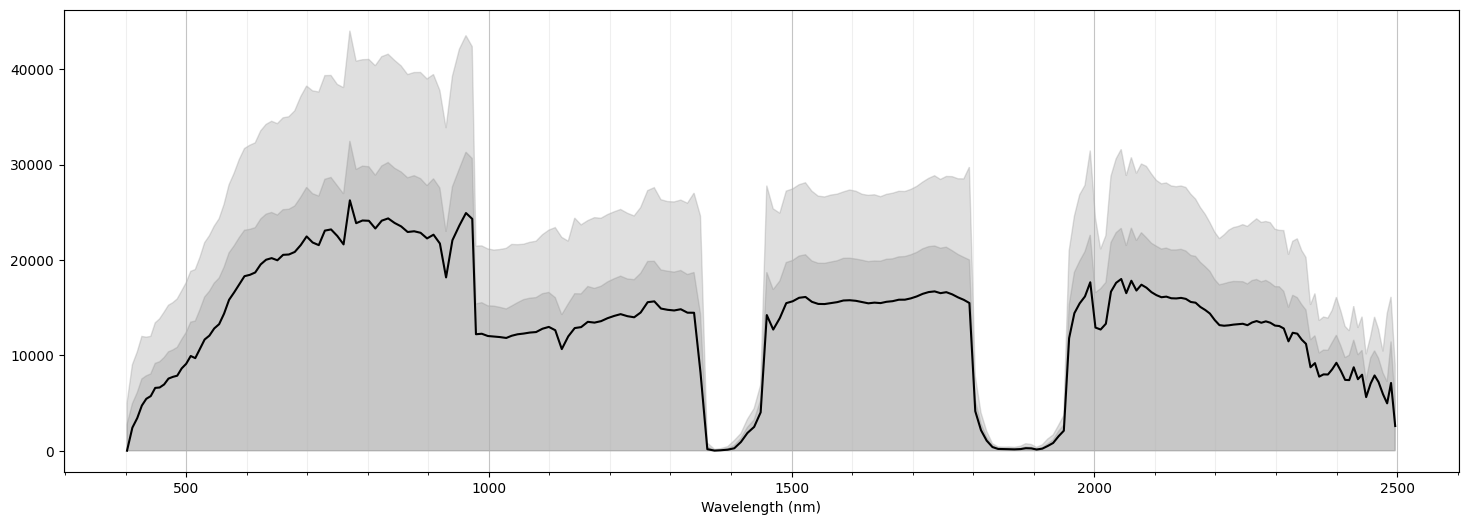

In [ ]:
HSI_im.plot_spectra()

(<Figure size 1800x1772.1 with 1 Axes>, <Axes: >)

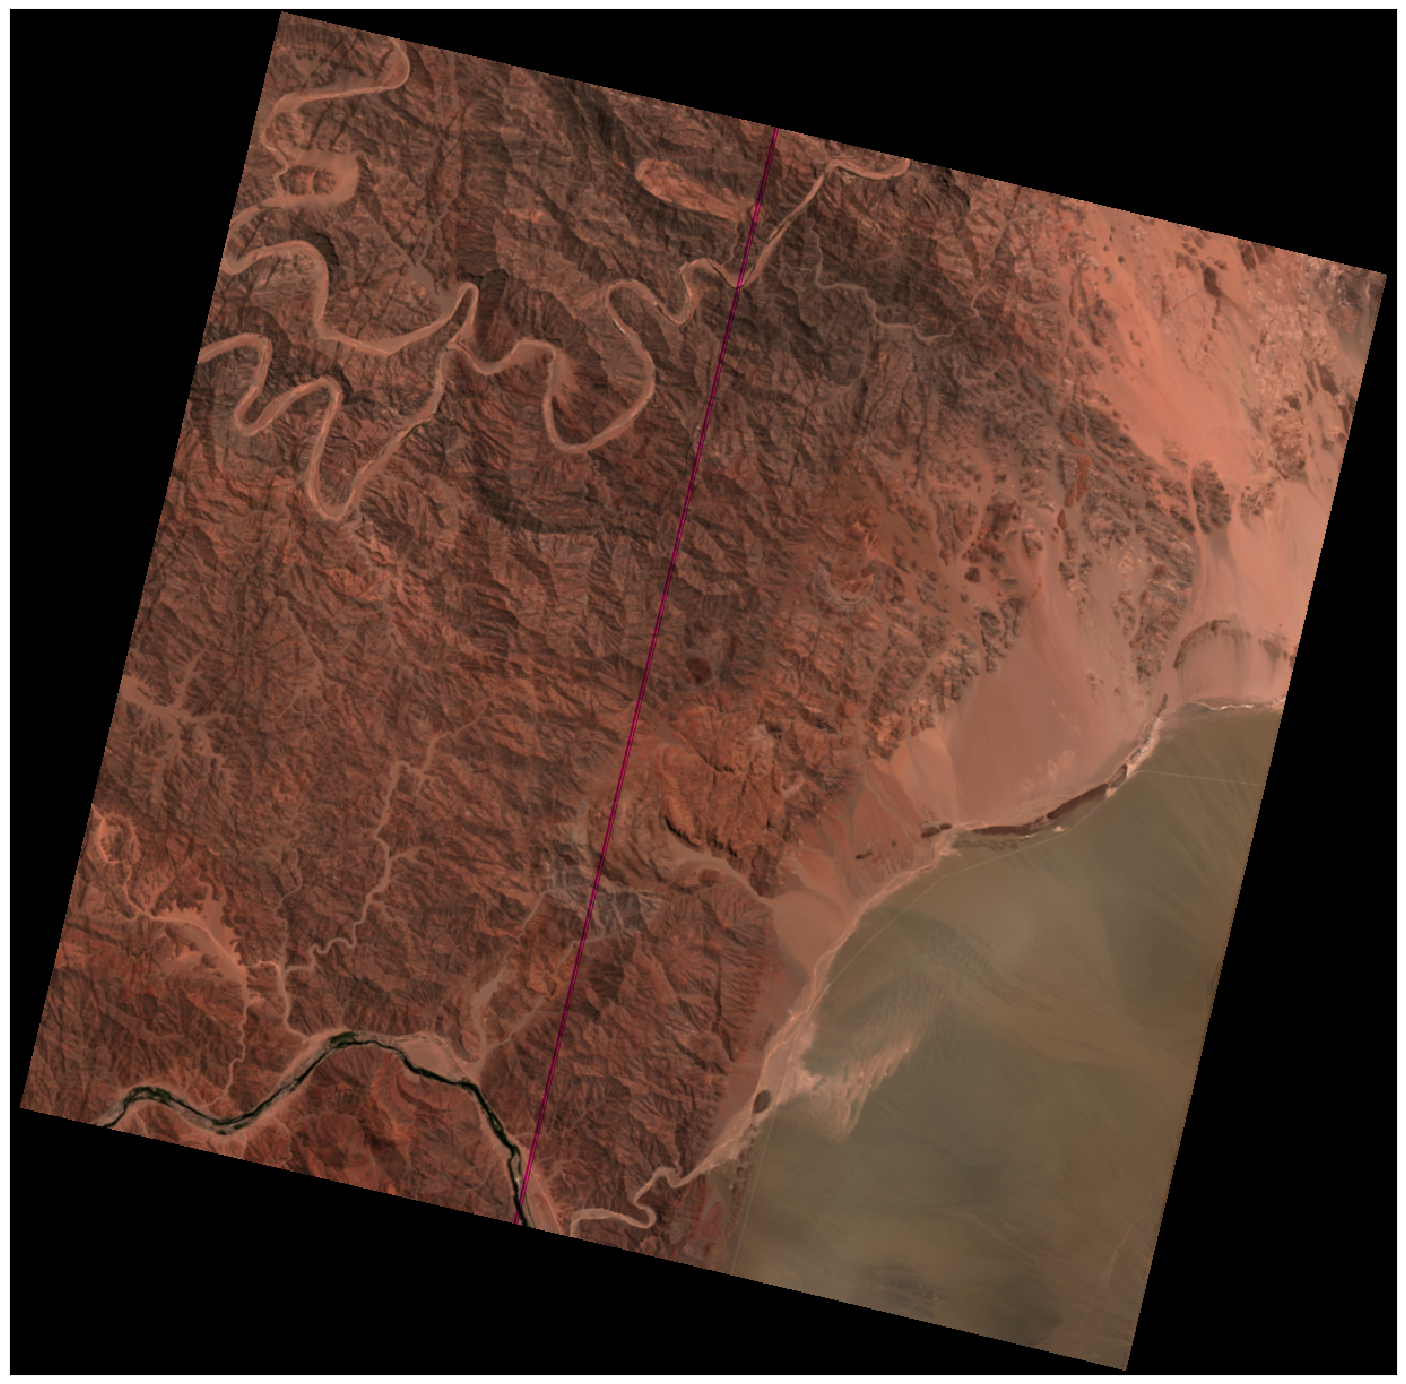

In [ ]:
HSI_im.quick_plot(hylite.RGB)

### (Optional) REMOVE CLOUDS

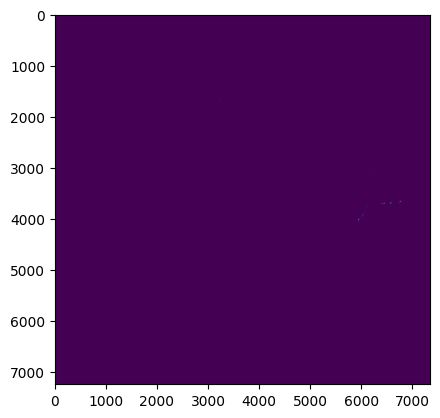

In [ ]:
# load and show the cloud cover mask
clouds = f['/HDFEOS/SWATHS/PRS_L2D_PCO/Data Fields/PIXEL_L2_ERR_MATRIX'][:,:]
plt.imshow(clouds)

In [ ]:
import cv2
cloud_resamp = np.transpose(cv2.resize(clouds, HSI_im.data.shape[0:2]))
HSI_im.data=HSI_im.data.astype(np.float)
HSI_im.mask(cloud_resamp>0)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [ ]:
HSI_im.quick_plot(hylite.RGB)

Output hidden; open in https://colab.research.google.com to view.

### SAVE TO DISK

In [ ]:
# N.B. saveWithGDAL is needed to preserve georeferencing information
# (if you don't care about this, just use io.save( ... ) ).
# ... saveWithGDAL requires GDAL to be installed.
#     To do this, running "conda install -c conda-forge gdal" can work
io.saveWithGDAL(MAIN + 'Prisma_Greenland_hsi',HSI_im)

### LOAD PANCHROMATIC

In [ ]:
pan = io.HyImage(np.transpose(f['/HDFEOS/SWATHS/PRS_L2D_PCO/Data Fields/Cube'][:,:]))
pan.set_projection_EPSG(epsg)
pan.affine = [easting, 5., 0., northing, 0.,-5.]
pan.quick_plot(band=0,cmap='Greys')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
io.saveWithGDAL(MAIN + 'Prisma_Greenland_pan',pan)

### IMPORTANT - CLOSE CONTAINER WHEN YOU ARE DONE

In [ ]:
f.close()